In [7]:
import sys
from os.path import dirname, realpath, join
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.stats import kendalltau

from Functions.method import PDRANK
from Functions.data_handle import Data
from tqdm.auto import tqdm

In [26]:
m = 30 # number of items
n_std_trial = np.linspace(0.3, 15, num=3, endpoint=True)
n_simulation_per_trial = 10

# Parameters for data generation
noise_type = 'constant' # type of noise in labels: 'constant', 'None' (no noise), 'BTL' (Bradley-Terry-Luce model)
noise_level = 0.1 # level of noise for noise_type = 'constant'
connectivity ='connected' # graph connective enforced: 'no', 'connected', 'strongly'
bt_interval = None # scores interval for BTL model

# Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
epsilon_out = 1e-2 # epsilon for stopping criterion of outer iterations. Recommended values of 1e-2 for m<500, 1e-1 otherwise
epsilon_in  = 1e-2 # epsilon for stopping criterion of inner iterations. Recommended values of 1e-2 for m<500, 1e-3 otherwise

In [27]:
def run_simulation(m,
                   n_pairs,
                   noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in):
    config = {
        'm': m,
        'n_pairs': n_pairs,
        'noise_type': noise_type,
        'noise_level': noise_level,
        'connectivity': connectivity,
        'bt_interval': bt_interval,
        'epsilon_out': epsilon_out,
        'epsilon_in': epsilon_in
    }
    # Generate comparison data with the required parameters
    data = Data(m,n_pairs,noise_type=noise_type,noise_level=noise_level, connectivity=connectivity,
                            bt_interval = bt_interval, demo=False)
                
    # If the connectivity is not None, the generated data may have a different number of items and comparisons
    real_m, real_n = data.m, data.n 
    x_gt = data.x # ground truth item scores
    x_gt_ranking = np.argsort(x_gt) # ground truth ranking

    # Data may be obtained in different formats (see methods in data_handle.py)
    # PD-Rank requires a matrix A with n rows and m columns, where n is the number of comparisons and m is the number of items.
    # Each row indicates a comparison between two items: with ones in the columns of the items being compared and zeros elsewhere.
    # The weights w_obs are the observed weights of the comparisons. I.e., the number of times each comparison was observed.
    # This only works if annotated behaviour is not included, as all observations of the same pair are aggregated for speed purposes.
    # If the annotated behaviour is desired, a different method must be implemented.
    if noise_type != 'random_annotator':
        A_unique, w_obs = data.get_Areduced_w()

        pdrank = PDRANK(epsilon_in=epsilon_in, epsilon_out=epsilon_out)
        x = pdrank.solve(A_unique, w_obs = w_obs) # solve the problem
        x_pdrank_ranking = np.argsort(x) # ranking obtained by pdrank

    else:
        A_full = data.get_A_full()

        pdrank = PDRANK(epsilon_in=epsilon_in, epsilon_out=epsilon_out)
        x = pdrank.solve(A_full) # solve the problem
        x_pdrank_ranking = np.argsort(x) # ranking obtained by pdrank
    result = kendalltau(x_gt_ranking, x_pdrank_ranking).statistic
    config['result'] = result
    return config

In [28]:
def run_exp(m, n_std_trial, n_simulation_per_trial, **kwargs):
    noise_type = kwargs.get('noise_type', 'constant')
    noise_level = kwargs.get('noise_level', 0.1)
    connectivity = kwargs.get('connectivity', 'connected')
    bt_interval = kwargs.get('bt_interval', None) # scores interval for BTL model
    
    # Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
    epsilon_out = kwargs.get('epsilon_out', 1e-2)
    epsilon_in  = kwargs.get('epsilon_in', 1e-2)
    
    n_comparisons = (n_std_trial*m*(m-1)/2).astype(int) # number of comparisons
    result = []
    for i, n_pairs in enumerate(tqdm(n_comparisons)):
        for j in range(n_simulation_per_trial):
            res = run_simulation(m, n_pairs, noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in)
            result.append(res)
    return result

In [29]:
from joblib import Parallel, delayed
# Parallel version of run_exp (for speed purpose)
def run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **kwargs):
    noise_type = kwargs.get('noise_type', 'constant')
    noise_level = kwargs.get('noise_level', 0.1)
    connectivity = kwargs.get('connectivity', 'connected')
    bt_interval = kwargs.get('bt_interval', None) # scores interval for BTL model
    
    # Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
    epsilon_out = kwargs.get('epsilon_out', 1e-2)
    epsilon_in  = kwargs.get('epsilon_in', 1e-2)
    
    n_comparisons = (n_std_trial*m*(m-1)/2).astype(int) # number of comparisons
    result = Parallel(n_jobs=4, verbose=10)(delayed(run_simulation)(m, n_pairs, noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in) for _ in range(n_simulation_per_trial) for n_pairs in n_comparisons)
    return result

In [30]:
# Can use the sequential version run_exp if you don't have joblib
kendall_taus = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, 
                                noise_type='constant',
                                noise_level = 0.1)
# Assume that there are 4 annotators with different noise levels
kendall_taus2 = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, 
                        noise_type = 'random_annotator', 
                        noise_level = np.array([0.1, 0.15, 0.2, 0.175]))

  0%|          | 0/3 [00:00<?, ?it/s]

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   22.7s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   41.7s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done  27 out of  30 | elapsed:  2.0min remaining:   13.5s
[Parallel(n_jobs=4)]: Done  30 out of  30 | elapsed:  2.3min finished


Text(0, 0.5, "Kendall's tau")

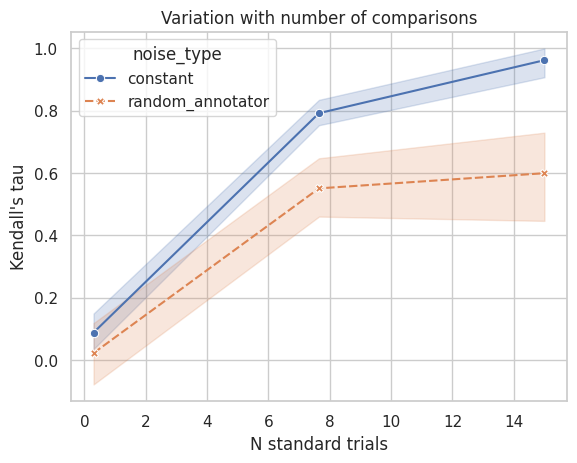

In [31]:
df = pd.concat([pd.DataFrame(kendall_taus), pd.DataFrame(kendall_taus2)]).sort_values(by='n_pairs')
df['n_std_trial'] = df['n_pairs'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='result', hue='noise_type', style='noise_type', markers=True)
g.set_title('Variation with number of comparisons')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")

In [58]:
g.get_figure().savefig('test_rnd_annotator_result.pdf', format='pdf', bbox_inches='tight')

In [35]:
# data = pd.DataFrame(np.hstack([
#     np.repeat(n_std_trial, n_simulation_per_trial).reshape(-1, 1), 
#     kendall_taus.reshape(-1,1), 
#     kendall_taus2.reshape(-1, 1)]), columns=['N std trials', 'constant', 'random_annotator'])
# data = pd.melt(data, id_vars='N std trials')
# df = data.rename(columns={'variable': 'Noise type', 'value': 'Kendall\'s tau'})
# # Set Seaborn style
# sns.set(style="whitegrid")
# g = sns.lineplot(data=df, x='N std trials', y='Kendall\'s tau', hue='Noise type')
# g.set_title('Variation with number of comparisons')